# T09 Baseline Model Development

This notebook fits exactly four baseline classifiers—Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting—using the existing chronological split and default T08 engineered representation. Models fit on Train only and are evaluated on Validation only. There is no tuning, resampling, feature selection, threshold optimization, final-model selection, or Test evaluation.

In [1]:
from pathlib import Path
from time import perf_counter
import hashlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data' / 'raw' / 'weatherAUS.csv').is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from fdm_rainfall.data import load_weather_data, chronological_train_validation_test_split
from fdm_rainfall.preprocessing import fit_transform_engineered_chronological_splits
from fdm_rainfall.modeling import (
    MODEL_NAMES, baseline_configuration_table, fit_and_evaluate_baselines,
    save_baseline_figures,
)

DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'weatherAUS.csv'
TABLE_DIR = PROJECT_ROOT / 'reports' / 'tables'
FIGURE_DIR = PROJECT_ROOT / 'reports' / 'figures' / 'baseline_models'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
EXPECTED_SHA256 = '573FD715CD69FCACC4DF32024D823B450AE3EDAAE7E8FF2EEB623ADBED424014'
pd.set_option('display.max_columns', 20)
pd.set_option('display.precision', 6)

## Data, chronological split, and leakage boundary

The raw labelled data follows the established order: whole-date chronological split → deterministic T08 feature engineering → preprocessing fitted on Train → Validation transformation. The standard preprocessing helper also transforms Test, but Test predictors and labels are never passed to a model or metric in this notebook.

In [2]:
raw_checksum = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest().upper()
assert raw_checksum == EXPECTED_SHA256
raw = load_weather_data(DATA_PATH)
split = chronological_train_validation_test_split(raw)
display(split.summary)
print('Raw SHA-256:', raw_checksum)

,Split,First date,Last date,Rows,Percentage of labelled rows,Unique dates,Locations,RainTomorrow No count,RainTomorrow Yes count,Yes percentage,Missing target count
0,Train,2007-11-01,2015-01-12,99546,70.007666,2541,49,77087,22459,22.561429,0
1,Validation,2015-01-13,2016-04-08,21342,15.009178,452,48,16990,4352,20.391716,0
2,Test,2016-04-09,2017-06-25,21305,14.983157,443,49,16239,5066,23.778456,0


Raw SHA-256: 573FD715CD69FCACC4DF32024D823B450AE3EDAAE7E8FF2EEB623ADBED424014


## Default T08 engineered preprocessing

Logistic Regression receives the existing scaled engineered path. The three tree-based baselines receive the existing unscaled engineered path. Both paths learn imputation, category encoding, and—where applicable—scaling from the same 99,546 Train rows only.

In [3]:
preprocess_start = perf_counter()
processed_unscaled = fit_transform_engineered_chronological_splits(split, scale_numeric=False)
processed_scaled = fit_transform_engineered_chronological_splits(split, scale_numeric=True)
preprocessing_seconds = perf_counter() - preprocess_start

assert processed_unscaled.X_train.shape == (99_546, 89)
assert processed_unscaled.X_validation.shape == (21_342, 89)
assert processed_scaled.X_train.shape == (99_546, 89)
assert processed_scaled.X_validation.shape == (21_342, 89)
assert processed_unscaled.y_train.equals(processed_scaled.y_train)
assert processed_unscaled.y_validation.equals(processed_scaled.y_validation)
assert processed_unscaled.preprocessor.fit_row_count_ == len(split.train)
assert processed_scaled.preprocessor.fit_row_count_ == len(split.train)

shape_table = pd.DataFrame([
    {'Split': 'Train', 'Rows': len(processed_unscaled.X_train), 'Processed features': processed_unscaled.X_train.shape[1], 'Role': 'Model fitting only'},
    {'Split': 'Validation', 'Rows': len(processed_unscaled.X_validation), 'Processed features': processed_unscaled.X_validation.shape[1], 'Role': 'Model evaluation only'},
])
shape_table.to_csv(TABLE_DIR / '09_processed_train_validation_shapes.csv', index=False)
display(shape_table)
print(f'Preprocessing both representations: {preprocessing_seconds:.3f} seconds')

,Split,Rows,Processed features,Role
0,Train,99546,89,Model fitting only
1,Validation,21342,89,Model evaluation only


Preprocessing both representations: 1.538 seconds


## Four baseline algorithms

- **Logistic Regression** is a simple interpretable linear reference and benefits from scaled continuous inputs.
- **Decision Tree** captures nonlinear relations and interactions without requiring scaling.
- **Random Forest** is a bagging ensemble that reduces the instability of a single tree and can combine mixed engineered weather signals.
- **Gradient Boosting** sequentially improves weak learners, captures nonlinear structure, and supplies an ensemble strategy distinct from bagging.

The estimators retain default model behaviour except for reproducibility (`random_state=42`), Logistic Regression convergence (`max_iter=1000`), and Random Forest execution parallelism (`n_jobs=-1`). These are technical execution settings, not tuned hyperparameters.

In [4]:
configuration = baseline_configuration_table()
configuration.to_csv(TABLE_DIR / '09_baseline_model_configurations.csv', index=False)
display(configuration)

,Model,Representation,Non-default execution settings,Purpose
0,Logistic Regression,"T08 engineered, scaled",max_iter=1000; random_state=42,Interpretable linear reference baseline
1,Decision Tree,"T08 engineered, unscaled",random_state=42,Single nonlinear tree baseline
2,Random Forest,"T08 engineered, unscaled",random_state=42; n_jobs=-1,Bagging ensemble baseline
3,Gradient Boosting,"T08 engineered, unscaled",random_state=42,Boosting ensemble baseline


## Train fitting and Validation-only evaluation

`RainTomorrow=Yes` is the positive class. Hard predictions use each model's default decision rule; probabilities are matched to the `Yes` entry in `model.classes_` rather than assuming a fixed probability-column position. Accuracy is shown but interpreted alongside balanced accuracy, Yes-class precision/recall/F1, ROC-AUC, and PR-AUC.

In [5]:
modeling_start = perf_counter()
evaluation = fit_and_evaluate_baselines(
    X_train_scaled=processed_scaled.X_train,
    X_validation_scaled=processed_scaled.X_validation,
    X_train_unscaled=processed_unscaled.X_train,
    X_validation_unscaled=processed_unscaled.X_validation,
    y_train=processed_unscaled.y_train,
    y_validation=processed_unscaled.y_validation,
)
modeling_seconds = perf_counter() - modeling_start

comparison = evaluation.comparison.copy()
assert comparison['Model'].tolist() == list(MODEL_NAMES)
comparison.to_csv(TABLE_DIR / '09_validation_baseline_comparison.csv', index=False)
comparison[['Model', 'TN', 'FP', 'FN', 'TP']].to_csv(
    TABLE_DIR / '09_validation_confusion_counts.csv', index=False
)
timings = evaluation.execution_times.copy()
timings.loc[len(timings)] = ['All four models', modeling_seconds, np.nan]
timings.loc[len(timings)] = ['Scaled + unscaled preprocessing', preprocessing_seconds, np.nan]
timings.to_csv(TABLE_DIR / '09_execution_times.csv', index=False)
display(comparison.style.format({column: '{:.6f}' for column in comparison.columns[1:8]}))
display(timings)

,Model,Accuracy,Balanced Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Logistic Regression,0.855028,0.705294,0.734701,0.452436,0.560011,0.868953,0.676829,16279,711,2383,1969
1,Decision Tree,0.793225,0.686902,0.493187,0.507353,0.500170,0.686902,0.350679,14721,2269,2144,2208
2,Random Forest,0.860416,0.703721,0.780318,0.439108,0.561976,0.880655,0.700227,16452,538,2441,1911
3,Gradient Boosting,0.857136,0.705336,0.750096,0.448989,0.561736,0.873906,0.690868,16339,651,2398,1954


,Model,Fit seconds,Validation prediction and probability seconds
0,Logistic Regression,1.020619,0.024002
1,Decision Tree,2.669156,0.036568
2,Random Forest,2.473500,0.188832
3,Gradient Boosting,32.657173,0.079003
4,All four models,40.008307,NaN
5,Scaled + unscaled preprocessing,1.537632,NaN


## Validation figures

The confusion matrices expose false negatives and false positives directly. ROC summarizes ranking across false-positive rates; Precision–Recall is especially informative here because the positive class is the minority and its no-skill reference is prevalence. The grouped metric chart prevents overall accuracy from standing alone.

reports\figures\baseline_models\09_validation_confusion_matrices.png


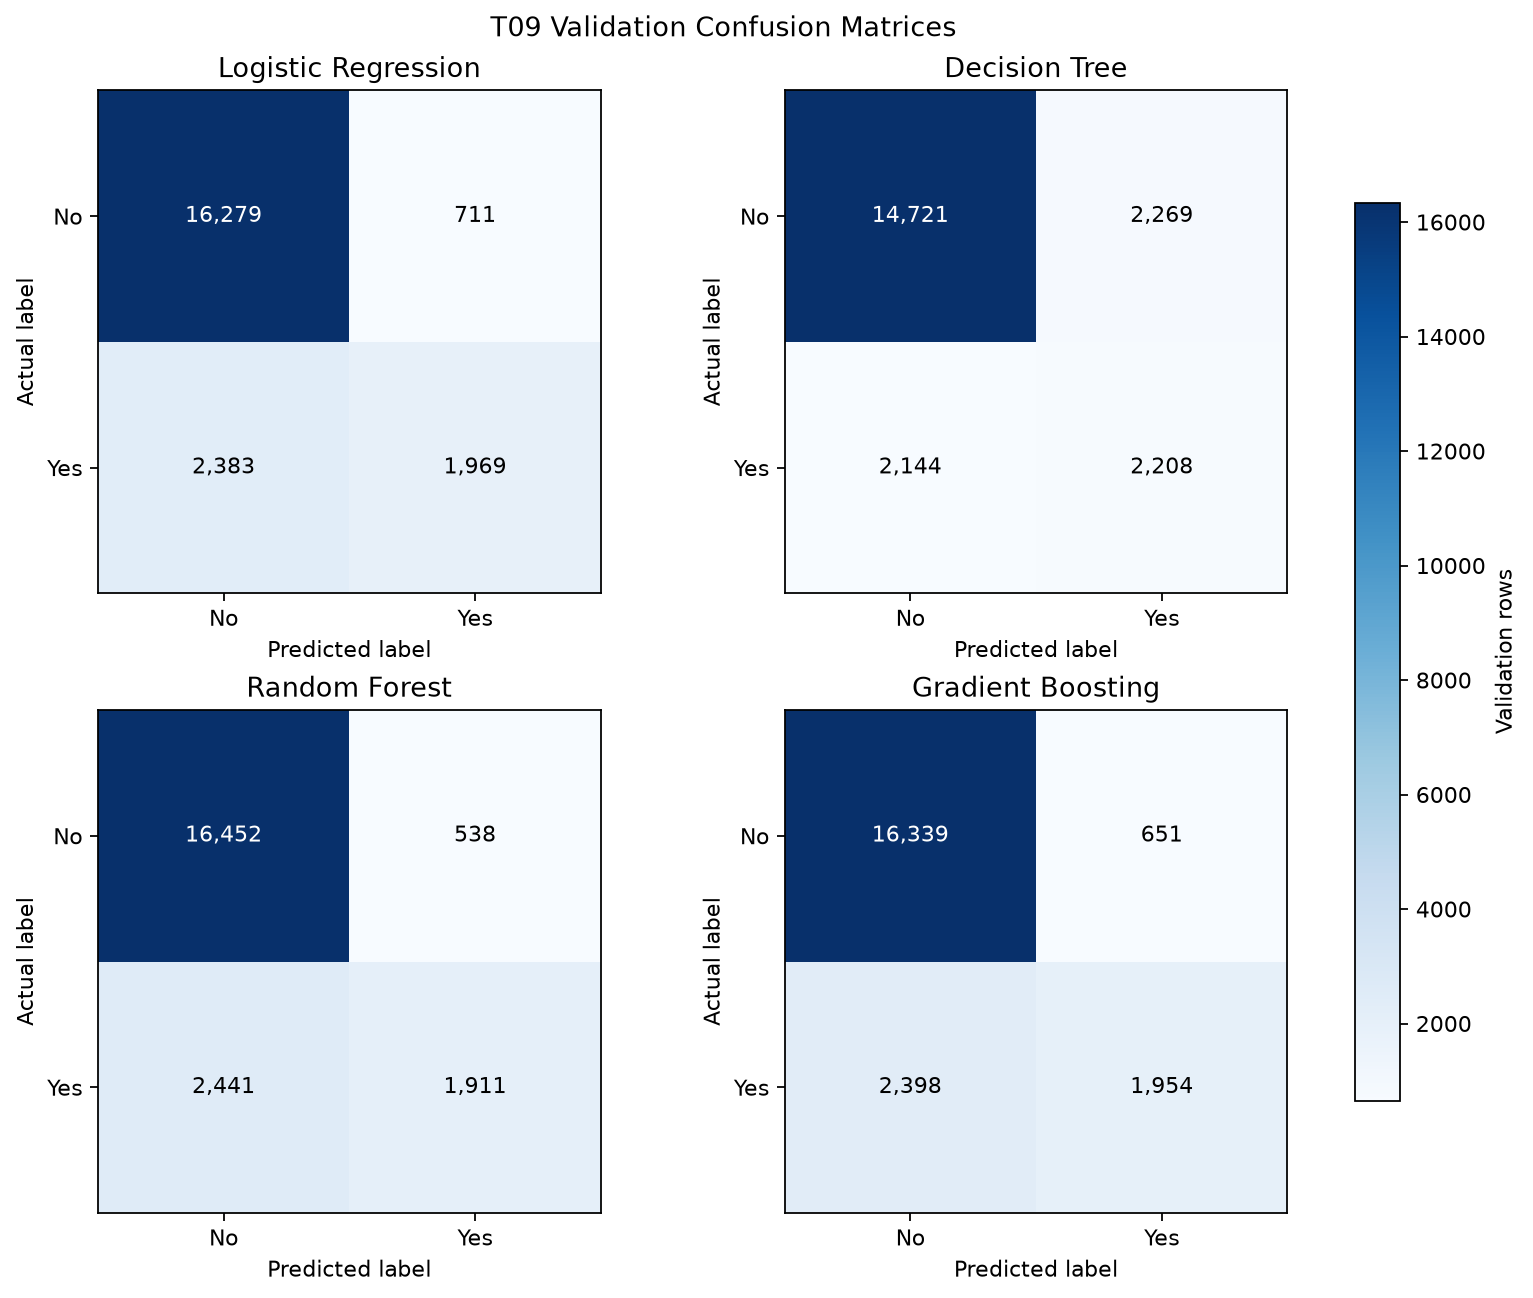

reports\figures\baseline_models\09_validation_roc_curves.png


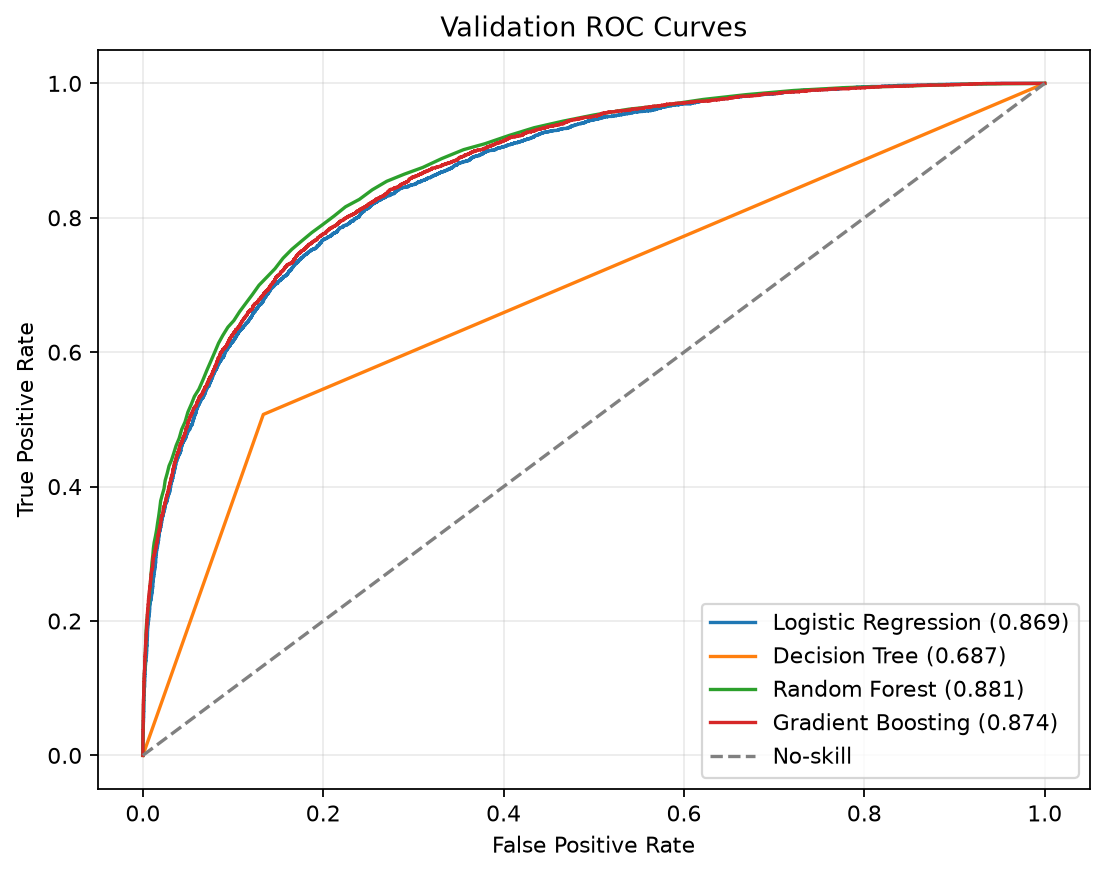

reports\figures\baseline_models\09_validation_precision_recall_curves.png


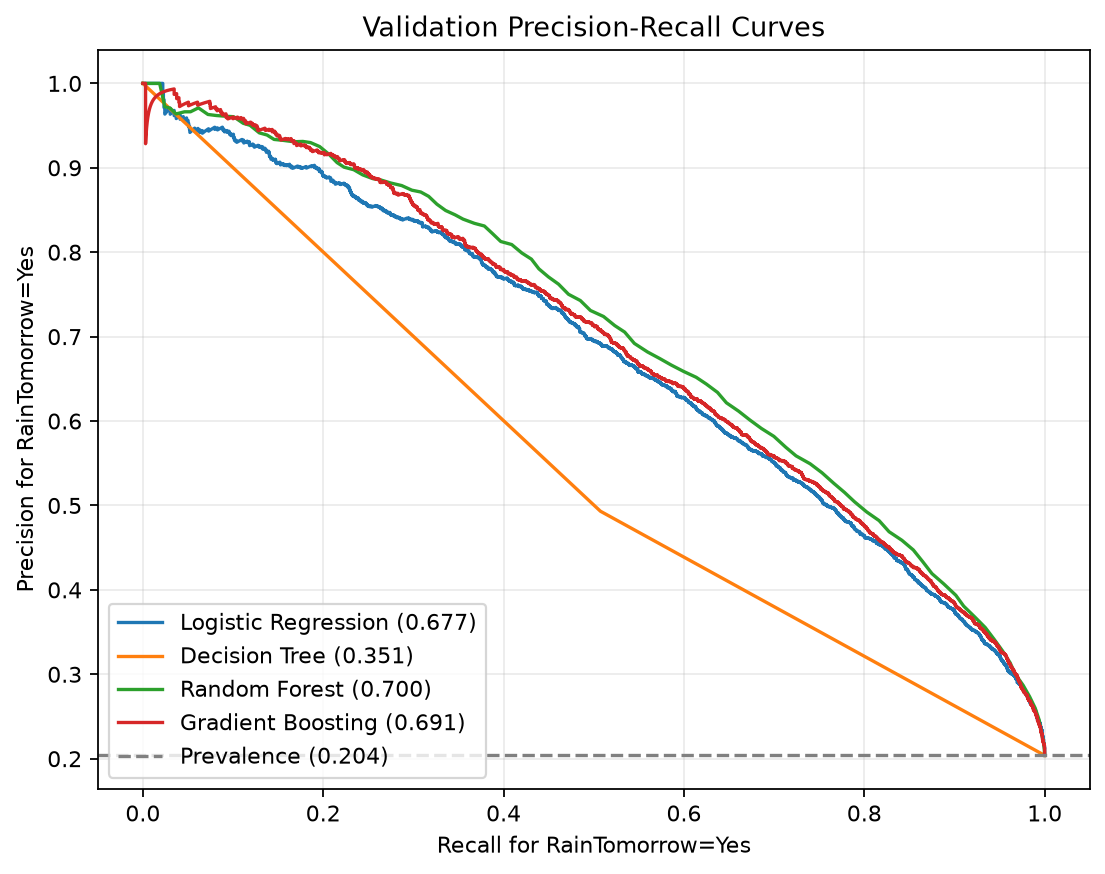

reports\figures\baseline_models\09_validation_metric_comparison.png


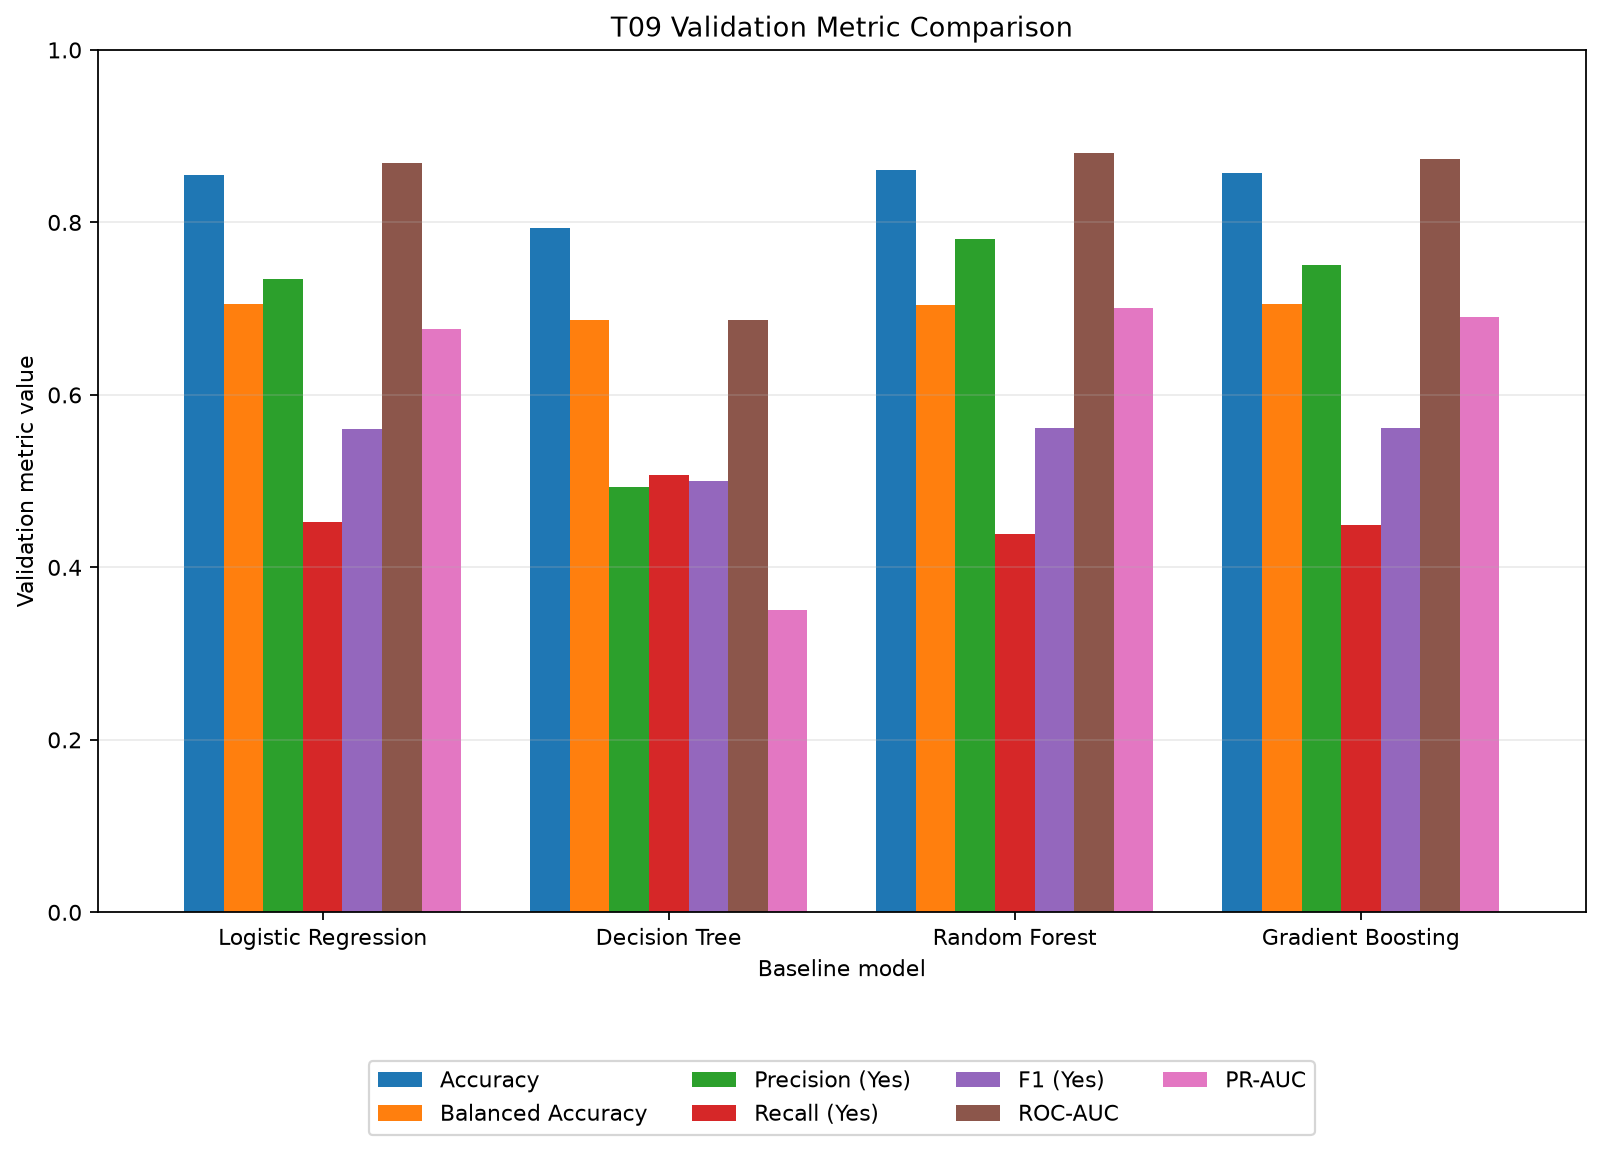

In [6]:
figure_paths = save_baseline_figures(
    evaluation, processed_unscaled.y_validation, FIGURE_DIR
)
for figure_path in figure_paths:
    print(figure_path.relative_to(PROJECT_ROOT))
    display(Image(filename=str(figure_path)))
plt.close('all')

## Interpretation framework

The comparison is evidence about untuned baselines, not a final-model decision. Precision and recall reflect different costs: false rain alerts reduce precision, while missed rain events reduce recall. Because `No` dominates, high accuracy can coexist with weak `Yes` recall; balanced accuracy and the confusion counts make that visible. PR-AUC focuses on positive-class retrieval and is more sensitive than ROC-AUC to performance on an imbalanced positive class. Differences among the linear, single-tree, bagging, and boosting baselines indicate how their distinct assumptions behave on the same engineered inputs; they do not establish causation.

In [7]:
metric_names = ['Accuracy', 'Balanced Accuracy', 'Precision (Yes)', 'Recall (Yes)', 'F1 (Yes)', 'ROC-AUC', 'PR-AUC']
leaders = {metric: comparison.loc[comparison[metric].idxmax(), 'Model'] for metric in metric_names}
validation_prevalence = float((processed_unscaled.y_validation == 'Yes').mean())
print(f'Validation Yes prevalence: {validation_prevalence:.6f}')
for metric, model_name in leaders.items():
    value = comparison.loc[comparison['Model'] == model_name, metric].iloc[0]
    print(f'Highest baseline {metric}: {model_name} ({value:.6f})')
print('These per-metric leaders are descriptive; no final model is selected in T09.')

Validation Yes prevalence: 0.203917
Highest baseline Accuracy: Random Forest (0.860416)
Highest baseline Balanced Accuracy: Gradient Boosting (0.705336)
Highest baseline Precision (Yes): Random Forest (0.780318)
Highest baseline Recall (Yes): Decision Tree (0.507353)
Highest baseline F1 (Yes): Random Forest (0.561976)
Highest baseline ROC-AUC: Random Forest (0.880655)
Highest baseline PR-AUC: Random Forest (0.700227)
These per-metric leaders are descriptive; no final model is selected in T09.


## Limitations and next-stage questions

These are untuned, default-threshold baselines on one chronological Validation period. They do not test resampling, class weighting, threshold trade-offs, hyperparameter alternatives, calibration, or feature alternatives. Those are possible T10+ questions only; none is answered here. Test remains reserved for a later final unbiased evaluation after development decisions are complete.

## Explicit T09 boundary

All four models were fitted on Train and evaluated only on Validation. No Test prediction, Test probability, Test metric, Test comparison, tuning, optimization, resampling, feature selection, or final-model selection was performed. Work stops at T09.

In [8]:
test_evaluated = False
assert test_evaluated is False
assert hashlib.sha256(DATA_PATH.read_bytes()).hexdigest().upper() == EXPECTED_SHA256
print('T09 boundary confirmed: Test was not evaluated; raw checksum remains unchanged.')

T09 boundary confirmed: Test was not evaluated; raw checksum remains unchanged.
